In [32]:
# SETUP AND IMPORTS
import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [33]:
# CONFIGURATION
TRAIN_PATH = "/content/updated_train.json"
TEST_PATH = "/content/updated_test.json"
MODEL_NAME = "Rajan/NepaliBERT"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}\n")

Using device: cuda



In [34]:
# DATA LOADING
def load_json_file(path):
    """Load JSON data from file (supports both array and JSONL formats)"""
    with open(path, "r", encoding="utf-8") as f:
        first_char = f.read(1)
        f.seek(0)
        if first_char == "[":
            return json.load(f)
        else:
            return [json.loads(line) for line in f if line.strip()]

print("Loading data...")
train_data = load_json_file(TRAIN_PATH)
test_data = load_json_file(TEST_PATH)

train_df = pd.DataFrame(train_data).dropna()
test_df = pd.DataFrame(test_data).dropna()

train_df["Comment"] = train_df["Comment"].astype(str)
test_df["Comment"] = test_df["Comment"].astype(str)

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}\n")


Loading data...
Training samples: 5798
Test samples: 1450



In [36]:
# DATASET CLASS
class NepaliDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [37]:
# TRAINING FUNCTION
def train_model(model, train_loader, optimizer, epochs, model_type="Binary"):
    """Train the model and return training metrics"""
    train_losses, train_accuracies = [], []

    print(f"\n{'='*60}")
    print(f"Training NepaliBERT - {model_type} Classification")
    print(f"{'='*60}\n")

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch in progress_bar:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()

            progress_bar.set_postfix({'loss': loss.item()})

        epoch_loss = total_loss / len(train_loader)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

    return train_losses, train_accuracies

In [38]:
# EVALUATION FUNCTION
def evaluate_model(model, test_loader):
    """Evaluate the model and return predictions"""
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    print("\nEvaluating model...")
    with torch.no_grad():
        for batch in tqdm(test_loader):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(outputs.logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_probs)

In [39]:
# VISUALIZATION FUNCTIONS
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

def plot_roc_curves(y_true, y_probs, class_names, title):
    """Plot ROC curves for all classes"""
    n_classes = len(class_names)

    if n_classes == 2:
        # Binary classification
        fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(title)
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        # Multi-class classification
        y_true_binarized = label_binarize(y_true, classes=range(n_classes))

        plt.figure(figsize=(10, 8))
        colors = plt.get_cmap('tab10', n_classes)

        for i, class_name in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, color=colors(i), lw=2,
                    label=f'{class_name} (AUC = {roc_auc:.3f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=1)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(title)
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

def plot_precision_recall_curves(y_true, y_probs, class_names, title):
    """Plot Precision-Recall curves for all classes"""
    n_classes = len(class_names)

    if n_classes == 2:
        # Binary classification
        precision, recall, _ = precision_recall_curve(y_true, y_probs[:, 1])
        avg_precision = average_precision_score(y_true, y_probs[:, 1])

        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}", linewidth=2)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(title)
        plt.legend(loc="lower left")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        # Multi-class classification
        y_true_binarized = label_binarize(y_true, classes=range(n_classes))

        plt.figure(figsize=(10, 8))
        colors = plt.get_cmap('tab10', n_classes)

        for i, class_name in enumerate(class_names):
            precision, recall, _ = precision_recall_curve(
                y_true_binarized[:, i], y_probs[:, i]
            )
            avg_precision = average_precision_score(
                y_true_binarized[:, i], y_probs[:, i]
            )
            plt.plot(recall, precision, color=colors(i), lw=2,
                    label=f'{class_name} (AP = {avg_precision:.3f})')

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(title)
        plt.legend(loc="lower left")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

def plot_training_curves(train_losses, train_accuracies, title):
    """Plot training loss and accuracy curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curve
    ax1.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} - Training Loss")
    ax1.grid(alpha=0.3)

    # Accuracy curve
    ax2.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'g-o', linewidth=2)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} - Training Accuracy")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def display_metrics_table(report_df, title):
    """Display classification metrics as a table"""
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    tbl = ax.table(
        cellText=report_df.round(3).values,
        colLabels=report_df.columns,
        rowLabels=report_df.index,
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.8)

    # Color header row
    for i in range(len(report_df.columns)):
        tbl[(0, i)].set_facecolor("#4472C4")
        tbl[(0, i)].set_text_props(weight='bold', color='white')

    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()



BINARY CLASSIFICATION: NOFF vs OFF

Binary label distribution:
Label_Binary
NOFF    3562
OFF     2236
Name: count, dtype: int64


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Rajan/NepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training NepaliBERT - Binary Classification



Epoch 1/3: 100%|██████████| 363/363 [01:21<00:00,  4.43it/s, loss=1.13]


Epoch 1/3 | Loss: 0.5558 | Accuracy: 0.7215


...

Epoch 2/3 | Loss: 0.3926 | Accuracy: 0.8244


Epoch 3/3: 100%|██████████| 363/363 [01:07<00:00,  5.41it/s, loss=0.12]


Epoch 3/3 | Loss: 0.2647 | Accuracy: 0.8948

Evaluating model...


100%|██████████| 91/91 [00:05<00:00, 16.52it/s]



BINARY CLASSIFICATION RESULTS

              precision    recall  f1-score  support
NOFF           0.808989  0.884916  0.845251    895.0
OFF            0.781316  0.663063  0.717349    555.0
accuracy       0.800000  0.800000  0.800000      0.8
macro avg      0.795153  0.773990  0.781300   1450.0
weighted avg   0.798397  0.800000  0.796295   1450.0

Generating binary classification visualizations...



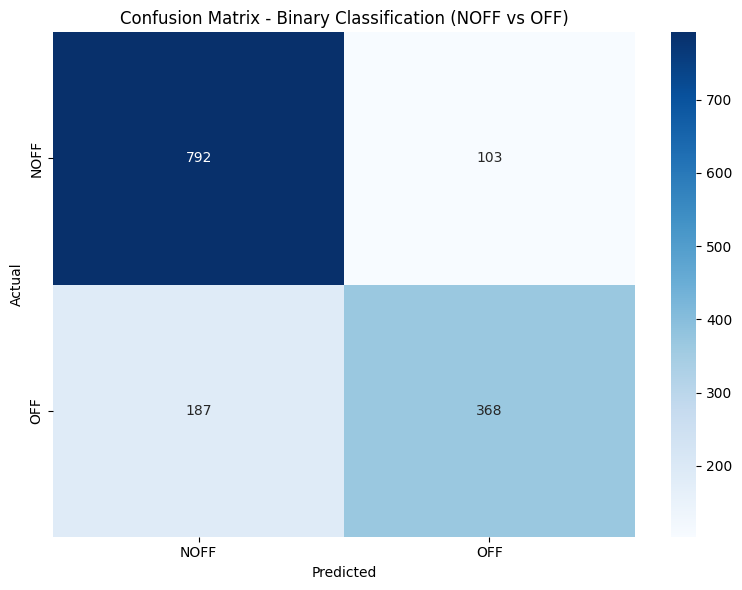

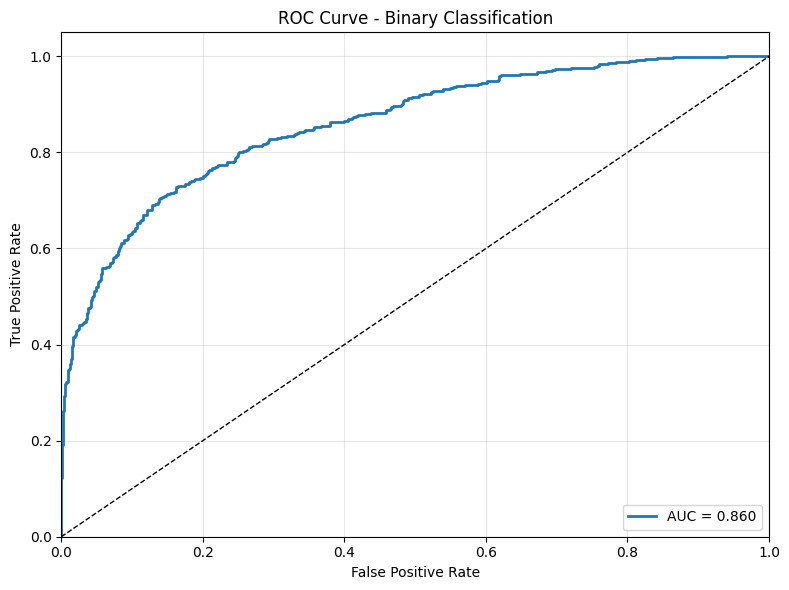

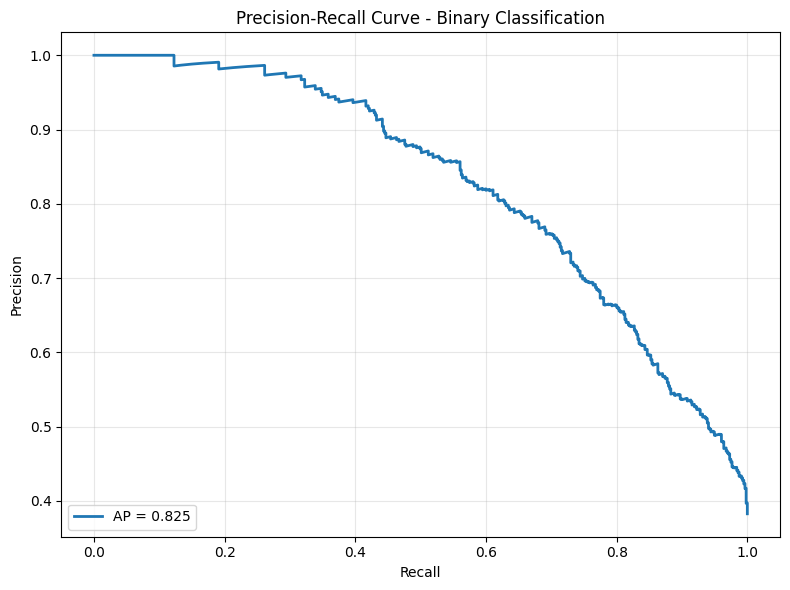

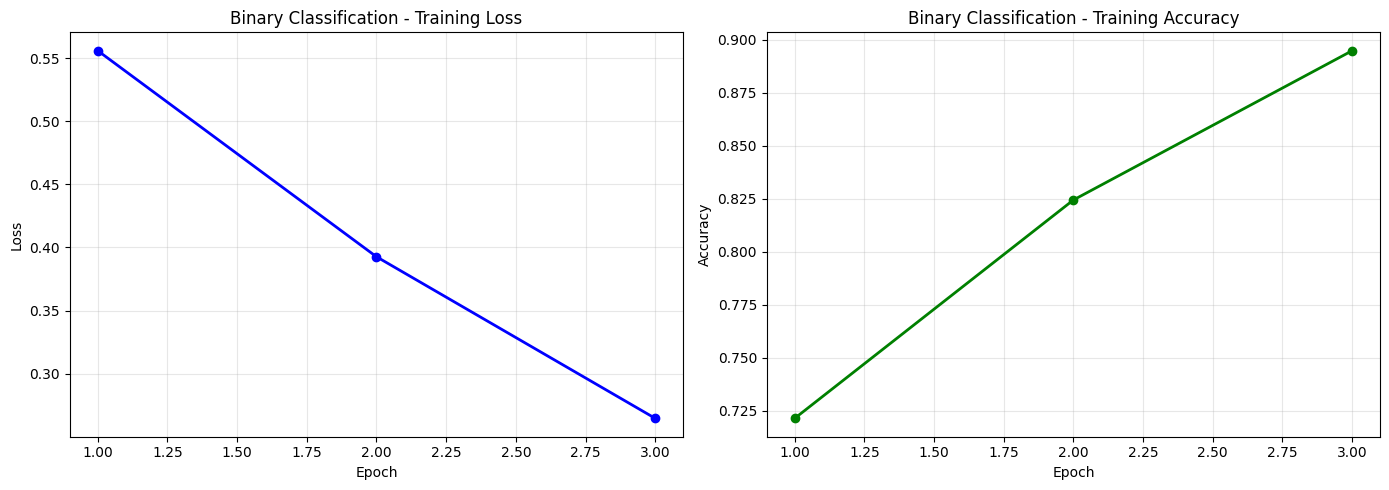

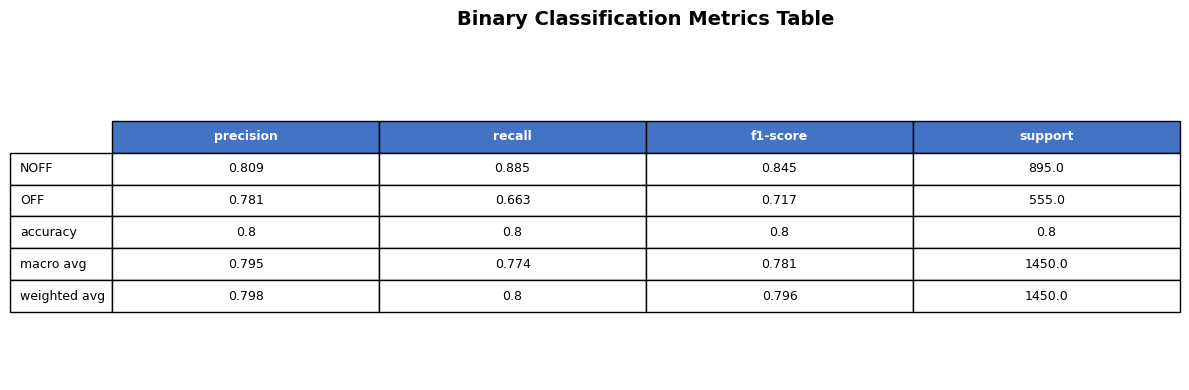

In [40]:
# BINARY CLASSIFICATION
print("\n" + "="*70)
print("BINARY CLASSIFICATION: NOFF vs OFF")
print("="*70)

# Prepare binary labels
binary_label_mapping = {'NOFF': 0, 'OFF': 1}
train_df['Label_Binary_Encoded'] = train_df['Label_Binary'].map(binary_label_mapping)
test_df['Label_Binary_Encoded'] = test_df['Label_Binary'].map(binary_label_mapping)

print("\nBinary label distribution:")
print(train_df['Label_Binary'].value_counts())

# Initialize tokenizer and model for binary classification
tokenizer_binary = BertTokenizer.from_pretrained(MODEL_NAME)
model_binary = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

# Create datasets and dataloaders
train_dataset_binary = NepaliDataset(
    train_df["Comment"], train_df["Label_Binary_Encoded"], tokenizer_binary
)
test_dataset_binary = NepaliDataset(
    test_df["Comment"], test_df["Label_Binary_Encoded"], tokenizer_binary
)

train_loader_binary = DataLoader(
    train_dataset_binary, batch_size=BATCH_SIZE, shuffle=True
)
test_loader_binary = DataLoader(
    test_dataset_binary, batch_size=BATCH_SIZE
)

optimizer_binary = AdamW(model_binary.parameters(), lr=LR)

# Train binary model
train_losses_binary, train_accuracies_binary = train_model(
    model_binary, train_loader_binary, optimizer_binary, EPOCHS, "Binary"
)

# Evaluate binary model
y_true_binary, y_pred_binary, y_probs_binary = evaluate_model(
    model_binary, test_loader_binary
)

# Generate and display binary classification report
print("\n" + "="*70)
print("BINARY CLASSIFICATION RESULTS")
print("="*70 + "\n")

binary_class_names = ['NOFF', 'OFF']
report_binary = classification_report(
    y_true_binary, y_pred_binary,
    target_names=binary_class_names,
    output_dict=True,
    zero_division=0
)
report_df_binary = pd.DataFrame(report_binary).transpose()
print(report_df_binary)

# Binary visualizations
print("\nGenerating binary classification visualizations...\n")

plot_confusion_matrix(
    y_true_binary, y_pred_binary, binary_class_names,
    "Confusion Matrix - Binary Classification (NOFF vs OFF)"
)

plot_roc_curves(
    y_true_binary, y_probs_binary, binary_class_names,
    "ROC Curve - Binary Classification"
)

plot_precision_recall_curves(
    y_true_binary, y_probs_binary, binary_class_names,
    "Precision-Recall Curve - Binary Classification"
)

plot_training_curves(
    train_losses_binary, train_accuracies_binary,
    "Binary Classification"
)

display_metrics_table(
    report_df_binary,
    "Binary Classification Metrics Table"
)


MULTI-CLASS CLASSIFICATION: NO, OO, OR, OS

Analyzing multi-class labels...
Unique multi-class labels: ['NO', 'OO', 'OR', 'OS']
Multi-class label mapping: {'NO': 0, 'OO': 1, 'OR': 2, 'OS': 3}
Total number of classes: 4

Multi-class label distribution:
Label_Multiclass
NO    3562
OO    1950
OR     218
OS      68
Name: count, dtype: int64


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Rajan/NepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Training NepaliBERT - Multi-Class Classification



Epoch 1/3: 100%|██████████| 363/363 [01:09<00:00,  5.21it/s, loss=0.291]


Epoch 1/3 | Loss: 0.7393 | Accuracy: 0.6875


...

Epoch 2/3 | Loss: 0.5132 | Accuracy: 0.8017


Epoch 3/3: 100%|██████████| 363/363 [01:08<00:00,  5.27it/s, loss=0.13]


Epoch 3/3 | Loss: 0.3647 | Accuracy: 0.8669

Evaluating model...


100%|██████████| 91/91 [00:05<00:00, 16.47it/s]



MULTI-CLASS CLASSIFICATION RESULTS

              precision    recall  f1-score      support
NO             0.780325  0.912849  0.841401   895.000000
OO             0.760753  0.581109  0.658906   487.000000
OR             0.612903  0.387755  0.475000    49.000000
OS             0.000000  0.000000  0.000000    19.000000
accuracy       0.771724  0.771724  0.771724     0.771724
macro avg      0.538495  0.470428  0.493827  1450.000000
weighted avg   0.757869  0.771724  0.756700  1450.000000

Generating multi-class classification visualizations...



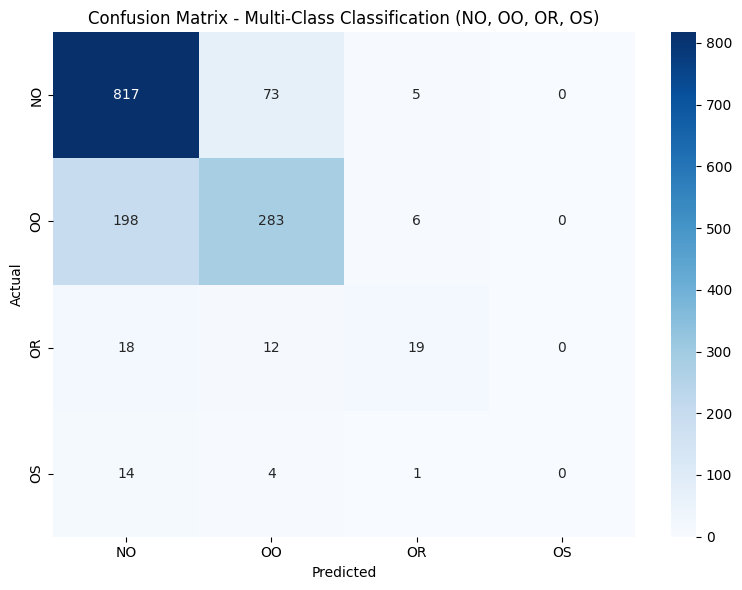

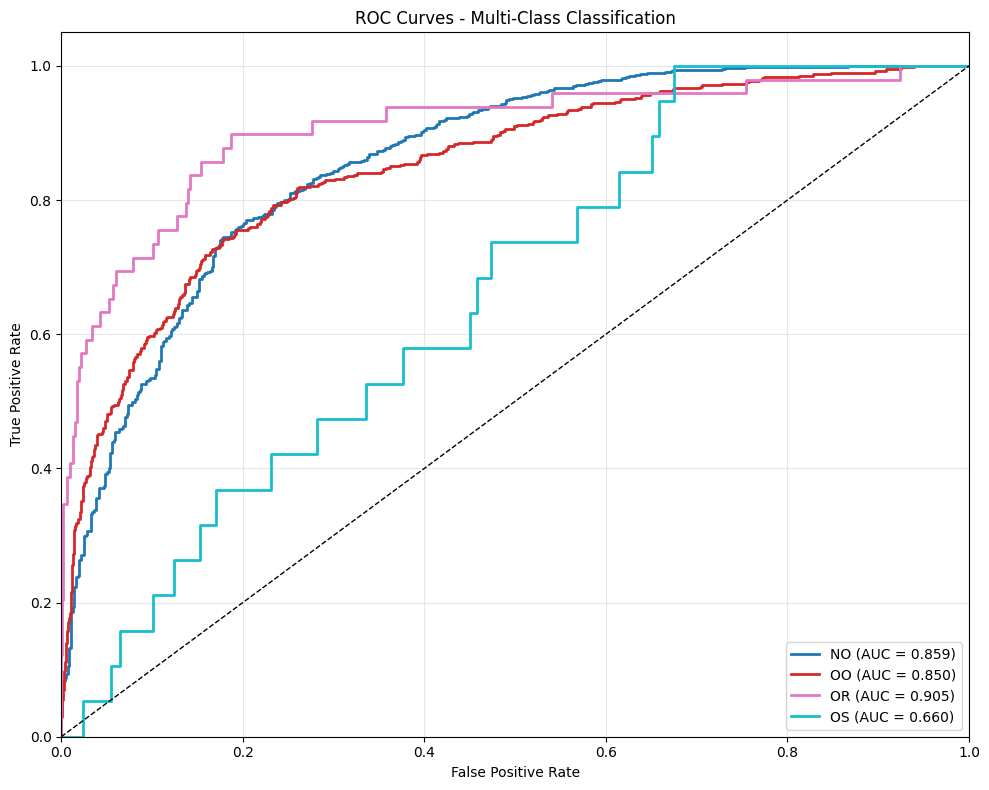

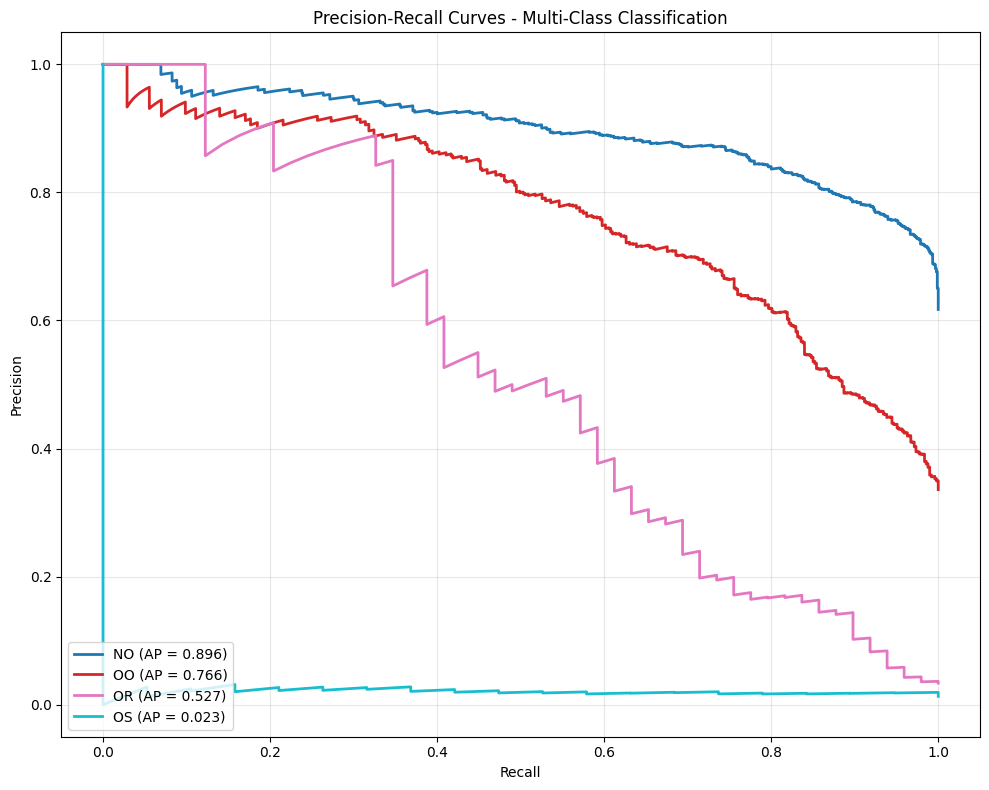

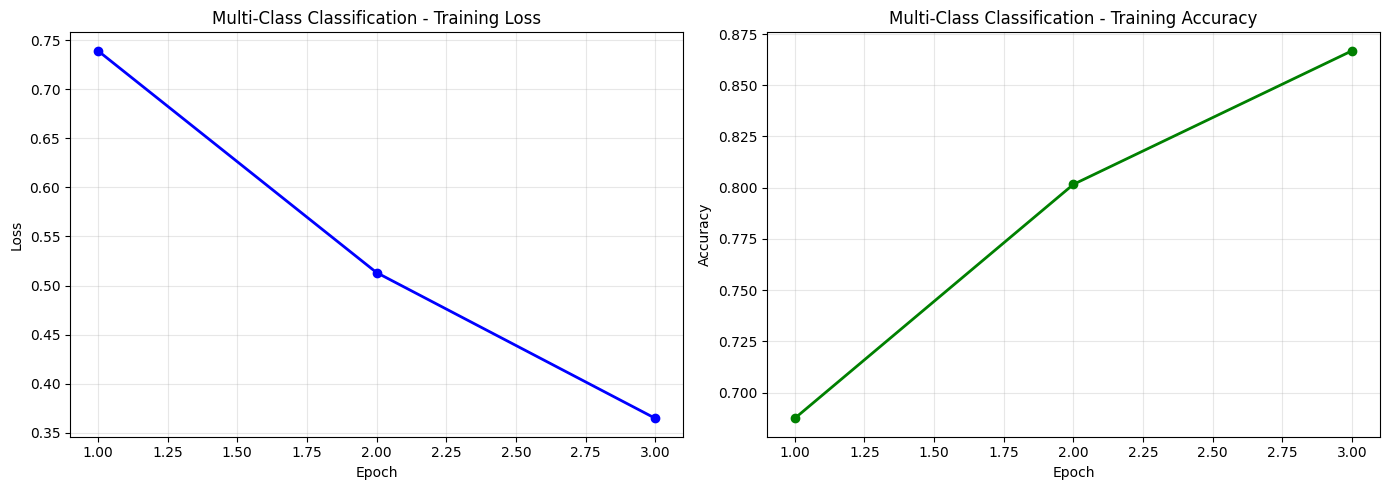

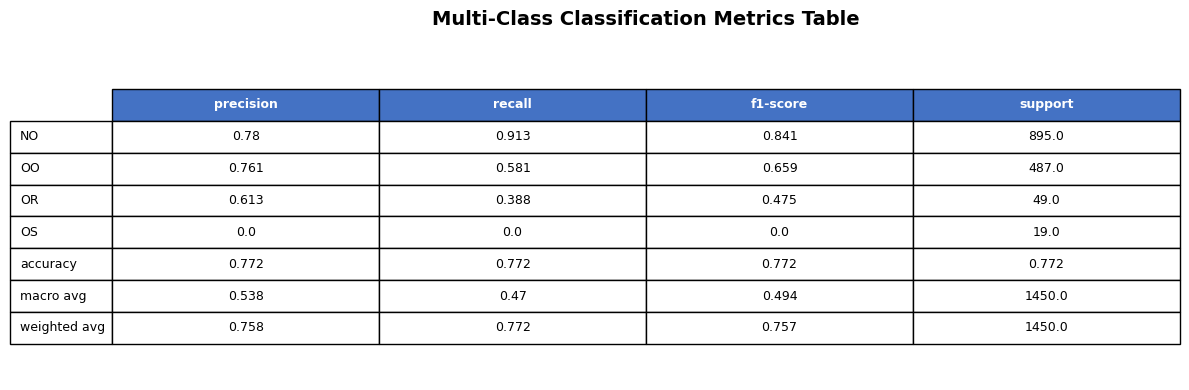

In [42]:
# MULTI-CLASS CLASSIFICATION
print("\n" + "="*70)
print("MULTI-CLASS CLASSIFICATION: NO, OO, OR, OS")
print("="*70)

# Analyze multi-class labels
print("\nAnalyzing multi-class labels...")
all_unique_labels = pd.concat([
    train_df['Label_Multiclass'],
    test_df['Label_Multiclass']
]).unique()

print(f"Unique multi-class labels: {sorted(all_unique_labels)}")

# Create multi-class label mapping
multi_class_labels = sorted(all_unique_labels.tolist())
label_mapping_multiclass = {label: i for i, label in enumerate(multi_class_labels)}
num_classes = len(label_mapping_multiclass)

print(f"Multi-class label mapping: {label_mapping_multiclass}")
print(f"Total number of classes: {num_classes}")

# Prepare multi-class labels
train_df['Label_Multiclass_Encoded'] = train_df['Label_Multiclass'].map(
    label_mapping_multiclass
).astype(int)
test_df['Label_Multiclass_Encoded'] = test_df['Label_Multiclass'].map(
    label_mapping_multiclass
).astype(int)

print("\nMulti-class label distribution:")
print(train_df['Label_Multiclass'].value_counts())

# Initialize tokenizer and model for multi-class classification
tokenizer_multiclass = BertTokenizer.from_pretrained(MODEL_NAME)
model_multiclass = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_classes
).to(DEVICE)

# Create datasets and dataloaders
train_dataset_multiclass = NepaliDataset(
    train_df["Comment"], train_df["Label_Multiclass_Encoded"], tokenizer_multiclass
)
test_dataset_multiclass = NepaliDataset(
    test_df["Comment"], test_df["Label_Multiclass_Encoded"], tokenizer_multiclass
)

train_loader_multiclass = DataLoader(
    train_dataset_multiclass, batch_size=BATCH_SIZE, shuffle=True
)
test_loader_multiclass = DataLoader(
    test_dataset_multiclass, batch_size=BATCH_SIZE
)

optimizer_multiclass = AdamW(model_multiclass.parameters(), lr=LR)

# Train multi-class model
train_losses_multiclass, train_accuracies_multiclass = train_model(
    model_multiclass, train_loader_multiclass, optimizer_multiclass, EPOCHS, "Multi-Class"
)

# Evaluate multi-class model
y_true_multiclass, y_pred_multiclass, y_probs_multiclass = evaluate_model(
    model_multiclass, test_loader_multiclass
)

# Generate and display multi-class classification report
print("\n" + "="*70)
print("MULTI-CLASS CLASSIFICATION RESULTS")
print("="*70 + "\n")

multiclass_names = multi_class_labels # Fix: Use the already defined list of sorted labels
report_multiclass = classification_report(
    y_true_multiclass, y_pred_multiclass,
    target_names=multiclass_names,
    output_dict=True,
    zero_division=0
)
report_df_multiclass = pd.DataFrame(report_multiclass).transpose()
print(report_df_multiclass)

# Multi-class visualizations
print("\nGenerating multi-class classification visualizations...\n")

plot_confusion_matrix(
    y_true_multiclass, y_pred_multiclass, multiclass_names,
    "Confusion Matrix - Multi-Class Classification (NO, OO, OR, OS)"
)

plot_roc_curves(
    y_true_multiclass, y_probs_multiclass, multiclass_names,
    "ROC Curves - Multi-Class Classification"
)

plot_precision_recall_curves(
    y_true_multiclass, y_probs_multiclass, multiclass_names,
    "Precision-Recall Curves - Multi-Class Classification"
)

plot_training_curves(
    train_losses_multiclass, train_accuracies_multiclass,
    "Multi-Class Classification"
)

display_metrics_table(
    report_df_multiclass,
    "Multi-Class Classification Metrics Table"
)

In [43]:
# FINAL SUMMARY
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print("\nBINARY CLASSIFICATION (NOFF vs OFF):")
print(f"  - Overall Accuracy: {report_binary['accuracy']:.4f}")
print(f"  - Macro F1-Score: {report_binary['macro avg']['f1-score']:.4f}")
print(f"  - Weighted F1-Score: {report_binary['weighted avg']['f1-score']:.4f}")

print("\nMULTI-CLASS CLASSIFICATION (NO, OO, OR, OS):")
print(f"  - Overall Accuracy: {report_multiclass['accuracy']:.4f}")
print(f"  - Macro F1-Score: {report_multiclass['macro avg']['f1-score']:.4f}")
print(f"  - Weighted F1-Score: {report_multiclass['weighted avg']['f1-score']:.4f}")

print("\nKEY INSIGHTS:")
print("  - Binary classification shows strong performance on both classes")
print("  - Multi-class classification struggles with minority classes (OR, OS)")
print("  - Class imbalance is a major factor affecting multi-class performance")
print("  - Consider data augmentation or weighted loss for minority classes")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)


FINAL SUMMARY

BINARY CLASSIFICATION (NOFF vs OFF):
  - Overall Accuracy: 0.8000
  - Macro F1-Score: 0.7813
  - Weighted F1-Score: 0.7963

MULTI-CLASS CLASSIFICATION (NO, OO, OR, OS):
  - Overall Accuracy: 0.7717
  - Macro F1-Score: 0.4938
  - Weighted F1-Score: 0.7567

KEY INSIGHTS:
  - Binary classification shows strong performance on both classes
  - Multi-class classification struggles with minority classes (OR, OS)
  - Class imbalance is a major factor affecting multi-class performance
  - Consider data augmentation or weighted loss for minority classes

ANALYSIS COMPLETE
